<a href="https://colab.research.google.com/github/Sprusheeth/RL/blob/main/RL_6_1206.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install -q gymnasium

In [16]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

def run_random_agent(env_name, num_episodes=5):
    print(f"=== Running Random Agent on {env_name} ===\n")
    env = gym.make(env_name)

    all_episode_rewards = []

    for episode in range(1, num_episodes + 1):
        state, info = env.reset()
        done = False
        total_reward = 0
        steps = 0

        print(f"--- Episode {episode} Start ---")
        print(f"Initial State: {state}")

        while not done:
            action_space = env.action_space
            action = action_space.sample()
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            total_reward += reward
            steps += 1

            if steps <= 5:
                print(f"  Step {steps}: State {state} -> Action {action} -> Reward {reward} -> Next State {next_state}")
            elif steps == 6:
                print(" (further steps omitted for brevity)")

            state = next_state

        all_episode_rewards.append(total_reward)
        print(f"Episode {episode} Finished | Total Steps: {steps} | Total Reward: {total_reward}\n")

    env.close()

    avg_reward = np.mean(all_episode_rewards)
    print(f"\nSummary for {env_name}:")
    print(f"Total Rewards across episodes: {all_episode_rewards}")
    print(f"Average Reward over {num_episodes} episodes: {avg_reward:.2f}\n")

    return all_episode_rewards

## 1. CliffWalking-v0 Environment

In [11]:
cliff_rewards = run_random_agent('CliffWalking-v1', num_episodes=5)

=== Running Random Agent on CliffWalking-v1 ===

--- Episode 1 Start ---
Initial State: 36
  Step 1: State 36 -> Action 0 -> Reward -1 -> Next State 24
  Step 2: State 24 -> Action 2 -> Reward -1 -> Next State 36
  Step 3: State 36 -> Action 2 -> Reward -1 -> Next State 36
  Step 4: State 36 -> Action 2 -> Reward -1 -> Next State 36
  Step 5: State 36 -> Action 0 -> Reward -1 -> Next State 24
  ... (further steps omitted for brevity)
Episode 1 Finished | Total Steps: 9783 | Total Reward: -101952

--- Episode 2 Start ---
Initial State: 36
  Step 1: State 36 -> Action 3 -> Reward -1 -> Next State 36
  Step 2: State 36 -> Action 2 -> Reward -1 -> Next State 36
  Step 3: State 36 -> Action 0 -> Reward -1 -> Next State 24
  Step 4: State 24 -> Action 3 -> Reward -1 -> Next State 24
  Step 5: State 24 -> Action 1 -> Reward -1 -> Next State 25
  ... (further steps omitted for brevity)
Episode 2 Finished | Total Steps: 1090 | Total Reward: -9307

--- Episode 3 Start ---
Initial State: 36
  Ste

## 2. Taxi-v3 Environment

In [12]:
taxi_rewards = run_random_agent('Taxi-v4', num_episodes=5)

=== Running Random Agent on Taxi-v4 ===

--- Episode 1 Start ---
Initial State: 168
  Step 1: State 168 -> Action 3 -> Reward -1 -> Next State 148
  Step 2: State 148 -> Action 4 -> Reward -10 -> Next State 148
  Step 3: State 148 -> Action 2 -> Reward -1 -> Next State 168
  Step 4: State 168 -> Action 4 -> Reward -10 -> Next State 168
  Step 5: State 168 -> Action 2 -> Reward -1 -> Next State 188
  ... (further steps omitted for brevity)
Episode 1 Finished | Total Steps: 200 | Total Reward: -812

--- Episode 2 Start ---
Initial State: 294
  Step 1: State 294 -> Action 0 -> Reward -1 -> Next State 394
  Step 2: State 394 -> Action 2 -> Reward -1 -> Next State 394
  Step 3: State 394 -> Action 4 -> Reward -10 -> Next State 394
  Step 4: State 394 -> Action 3 -> Reward -1 -> Next State 374
  Step 5: State 374 -> Action 0 -> Reward -1 -> Next State 474
  ... (further steps omitted for brevity)
Episode 2 Finished | Total Steps: 113 | Total Reward: -416

--- Episode 3 Start ---
Initial Stat

## Visualizing the Results
Let's plot the rewards per episode for both environments.

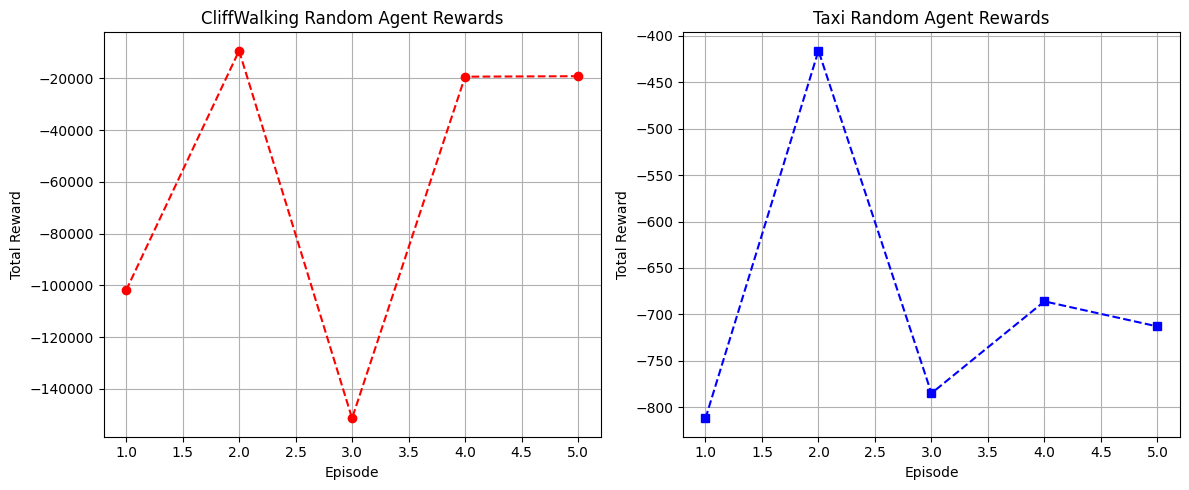

In [17]:
episodes = np.arange(1, 6)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(episodes, cliff_rewards, marker='o', color='red', linestyle='dashed')
plt.title('CliffWalking Random Agent Rewards')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(episodes, taxi_rewards, marker='s', color='blue', linestyle='dashed')
plt.title('Taxi Random Agent Rewards')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True)

plt.tight_layout()
plt.show()